# TEXAS — Google Colab Quickstart

**TEXAS** (`texas-psm`) is a Bayesian proxy system model for TEX<sub>86</sub> paleothermometry.

This notebook walks through:
1. Installing CmdStan and the package
2. Downloading the pre-computed posteriors from Zenodo
3. **Forward prediction** — temperature → Scaled RI (pure Python, no Stan)
4. **Inverse reconstruction** — Scaled RI → temperature with full uncertainty (runs Stan)

---

> **Saving your work**: This notebook runs on a temporary Colab session. To keep your edits, go to **File → Save a copy in Drive** before making changes.

> **What requires Stan?**
> | Task | Stan needed? |
> |------|-------------|
> | `predict_proxy_from_T()` — plot calibration curve | ❌ No |
> | `predict_T_from_proxyObs()` — reconstruct paleotemperature | ✅ Yes |
> | `get_posterior()` — re-fit the calibration from scratch | ✅ Yes |

---

### Step 1a — Install CmdStan on Google Colab

In [ ]:
# ── Step 1a: Install CmdStan ───────────────────────────────────────────────────
# Required before importing TEXAS. Skip this cell only if you need forward
# prediction (predict_proxy_from_T) and NOT inverse reconstruction.
# Takes ~5–10 minutes. Must be re-run each new Colab session.
!pip install -q cmdstanpy
import cmdstanpy
cmdstanpy.install_cmdstan(version="2.36.0", progress=True)
print(f"✅ CmdStan ready: {cmdstanpy.cmdstan_path()}")

### Step 1b — Install TEXAS

In [ ]:
# ── Step 1b: Install TEXAS ─────────────────────────────────────────────────────
!pip install -q texas-psm

In [1]:
import TEXAS
print(f"TEXAS version: {TEXAS.__version__}")

TEXAS version: 0.1.7


---

## Step 2 — Mount Google Drive (optional)

Mount your Drive if your proxy data or posteriors are stored there.
Skip this cell if you plan to upload files directly or use the Zenodo download below.

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

# Set a base path for your data on Drive — change to your folder:
DRIVE_BASE = "/content/drive/MyDrive/texas"

import os
os.makedirs(DRIVE_BASE, exist_ok=True)
print(f"Drive mounted. Working folder: {DRIVE_BASE}")

---

## Step 3 — Download the pre-computed posteriors

The forward calibration posteriors (`.nc` files) are required for both forward
and inverse predictions. Download them once from Zenodo — they are cached for
the session. If you mounted Google Drive above, point the cache there so you
don't re-download every session.

In [2]:
import os
import TEXAS

# ── Option A: cache posteriors on Google Drive (survives session restarts) ─────
# Uncomment after mounting Drive in Step 2:
# os.environ["TEXAS_CACHE_DIR"] = f"{DRIVE_BASE}/posteriors"

# ── Option B: cache in ephemeral Colab storage (re-downloaded each session) ────
# Nothing to set — default cache is used automatically.

# ── Download all posteriors from Zenodo (~560 MB ZIP, extracted ~315 MB) ───────
# TEXAS.download_all()

# ── Or download just the canonical posteriors (recommended) ────────────────────
TEXAS.download_posteriors([
    "gen_logi_fixed_hier_crtp_univ_priorApprox_SST_scaledRI_cren3",
    "gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_SST_gdgt23ratio_no3_1.0_scaledRI_cren3",
])

ZIP saved to /tmp/texas-psm-zenodo-v0.1.5.zip
Extracted → /home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_univ_priorApprox_SST_scaledRI_cren3.nc
Extracted → /home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_SST_gdgt23ratio_no3_1.0_scaledRI_cren3.nc


[PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_univ_priorApprox_SST_scaledRI_cren3.nc'),
 PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_SST_gdgt23ratio_no3_1.0_scaledRI_cren3.nc')]

### Inspect your forward model posteriors of fitted parameters

In [27]:
from TEXAS import load_posterior


fname = f'gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_SST_gdgt23ratio_no3_1.0_scaledRI_cren3'

### load_posterior() can take only file name (no *.nc file type in the string) an auto-detect whether
### the file is available from the data/cache/TEXAS_posterior_cache/ (this is a default cache dir; users can set a specific cache dir)
test_ds = load_posterior(fname)

display(test_ds)

<xarray.Dataset>
Dimensions:                (chain: 4, draw: 1000,
                            true_gdgt23ratio_crtp_dim_0: 1513,
                            true_no3_crtp_dim_0: 1513)
Coordinates:
  * chain                  (chain) int64 1 2 3 4
  * draw                   (draw) int64 0 1 2 3 4 5 ... 994 995 996 997 998 999
Dimensions without coordinates: true_gdgt23ratio_crtp_dim_0, true_no3_crtp_dim_0
Data variables:
    t0_crtp                (chain, draw) float64 36.91 34.23 ... 36.87 36.95
    k_crtp                 (chain, draw) float64 0.3679 0.1521 ... 0.2191 0.2271
    b_crtp                 (chain, draw) float64 0.4325 0.4306 ... 0.4334 0.4335
    v_crtp                 (chain, draw) float64 5.352 1.924 ... 3.16 3.257
    beta_G23_crtp          (chain, draw) float64 -0.006329 ... -0.005282
    beta_NO3_crtp          (chain, draw) float64 -0.04181 -0.04415 ... -0.05143
    sigma_proxyObs_crtp    (chain, draw) float64 0.04145 0.04162 ... 0.04108
    true_gdgt23ratio_crtp  (chain, draw, true_gdgt23ratio_crtp_dim_0) float64 ...
    true_no3_crtp          (chain, draw, true_no3_crtp_dim_0) float64 0.5059 ...
    R2_full                (chain, draw) float64 0.7985 0.7973 ... 0.801 0.8049
    bayesR2_full           (chain, draw) float64 0.865 0.8618 ... 0.8555 0.8629
    RMSE_full              (chain, draw) float64 0.05133 0.05149 ... 0.05051
Attributes: (12/45)
    stan_version:                 2.36.0
    model:                        gen_logi_fixed_hier_crtp_multiv_priorApprox...
    num_draws_sampling:           1000
    stan_model_name:              gen_logi_fixed_hier_crtp_multiv_priorApprox...
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    ...                           ...
    stan_diag_n_high_rhat:        1
    stan_diag_rhat_status:        FAIL
    stan_diag_min_ess_bulk:       1239.92
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     FAIL
    filename:                     gen_logi_fixed_hier_crtp_multiv_priorApprox...

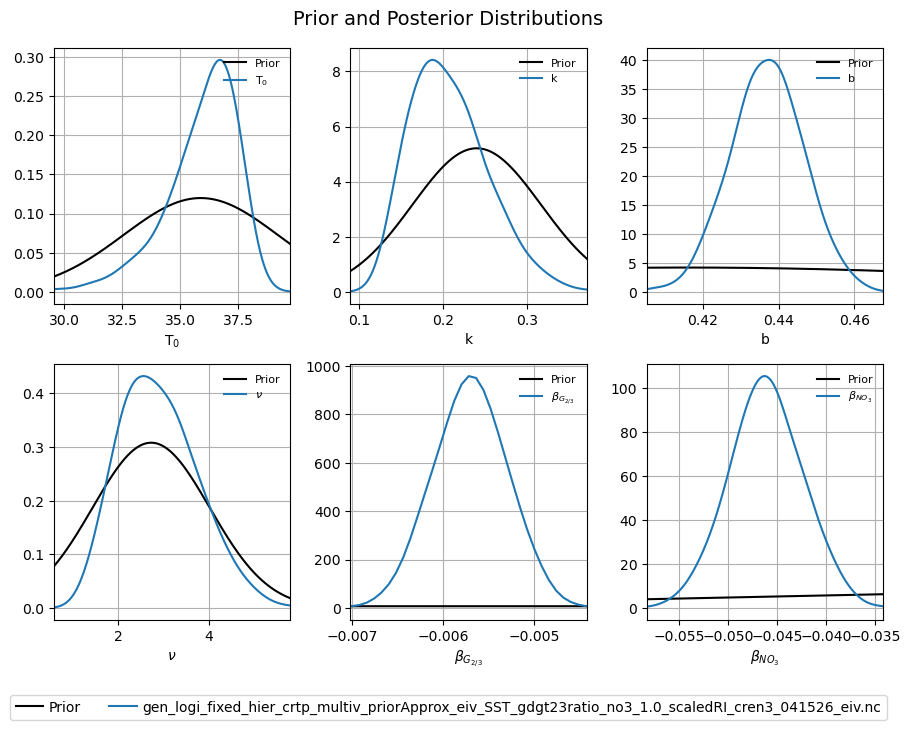

In [28]:
from TEXAS import plot_prior_distributions
fig, axs = plot_prior_distributions(
    priors_list = test_ds.attrs['priors'],
    posterior_datasets=[test_ds],
    show_histogram=False,
    show_prior_expression=False)

---

## Step 4 — Forward prediction: temperature → Scaled RI

`predict_proxy_from_T()` evaluates the calibration curve at a range of
temperatures. **No Stan required** — this is pure Python using the loaded posterior.

Use this to visualise the calibration curve or to generate forward-model
predictions from a temperature ensemble.

### Start with a toy data; simple linspace array

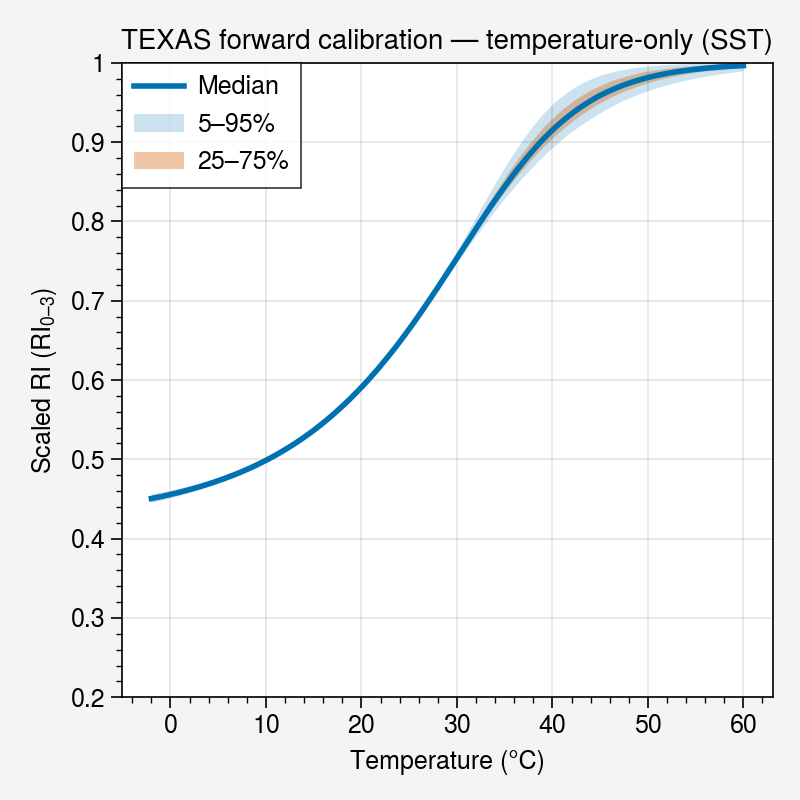

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import proplot as plot
import pandas as pd
from TEXAS import predict_proxy_from_T


### In this example, temperatures is a linspace array; an evenly-spaced array of n values between a and b in np.linspace(a,b,n)
temperatures = np.linspace(-2,60, 200)


## Temperature-only posterior (SST, canonical Scaled RI₀₋₃)
## A default value for n_draws is set at 500 --- n_draws is the number of posterior ensemble members used for forward modeling
## The function predict_proxy_from_T() uses each paired-parameters solved from the CmdStan (MCMC) to build an S-curve ensemble
## Percentiles (e.g., "p50") are calculated from the n_draws number of S-curve ensembles generate
## the pre-computed forward model posteriors used in TEXAS have 4000 members (4 chains x 1000 draws per chain)

set_n_draw = 1500 ### The code is default at 5000 if n_draws is not provided in the function signature.
result = predict_proxy_from_T(
    temperatures=temperatures,
    n_draws=set_n_draw,
    posterior="gen_logi_fixed_hier_crtp_univ_priorApprox_SST_scaledRI_cren3",
    percentiles=[5, 25, 50, 75, 95],
)

# Plot calibration curve with uncertainty
fig, ax = plt.subplots(figsize=(4, 4))
ax.fill_between(temperatures, result["p5"],  result["p95"], alpha=0.2,  label="5–95%")
ax.fill_between(temperatures, result["p25"], result["p75"], alpha=0.35, label="25–75%")
ax.plot(temperatures, result["p50"], lw=2, label="Median")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel(u"Scaled RI (RI$_{0\u20133}$)")
ax.set_title("TEXAS forward calibration — temperature-only (SST)")
ax.set_ylim(0.2,1)
ax.legend()
plt.tight_layout()
plt.show()

---

## Step 5 — Inverse reconstruction: Scaled RI → temperature

`predict_T_from_proxyObs()` reconstructs paleotemperatures from observed
Scaled RI values. **Requires CmdStan** (Step 1b).

Replace the example data below with your own downcore or coretop Scaled RI
observations.

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from TEXAS import predict_T_from_proxyObs

# ── Load your data ─────────────────────────────────────────────────────────────
# Option A — from Google Drive (uncomment after Step 2):
# df = pd.read_csv(f"{DRIVE_BASE}/my_coretop_data.csv")

# Option B — upload interactively:
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv(list(uploaded.keys())[0])

# Option C — example synthetic data (replace with your own):
np.random.seed(42)
n = 10
scaledRI_obs = np.random.uniform(0.35, 0.75, n)   # your downcore Scaled RI₀₋₃ values

# ── Run inverse reconstruction ─────────────────────────────────────────────────
result = predict_T_from_proxyObs(
    proxyObs       = scaledRI_obs,
    prior_mu_t     = 15.0,    # prior mean temperature (°C) — set to your best site estimate
    prior_sigma_t  = 10.0,    # prior uncertainty (°C) — use ~10 when uncertain
    fwd_posterior_name = "gen_logi_fixed_hier_crtp_univ_priorApprox_SST_scaledRI_cren3",
    temptype       = "SST",
)

# ── Plot results ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
idx = np.arange(n)
ax.fill_between(idx, result["p5"], result["p95"], alpha=0.25, label="5–95% CI")
ax.fill_between(idx, result["p25"], result["p75"], alpha=0.4, label="25–75% CI")
ax.plot(idx, result["p50"], "o-", ms=5, lw=1.5, label="Median")
ax.set_xlabel("Sample index")
ax.set_ylabel("Reconstructed SST (°C)")
ax.set_title("TEXAS inverse reconstruction — temperature-only model")
ax.legend()
plt.tight_layout()
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────────
results_df = pd.DataFrame({
    "scaledRI":  scaledRI_obs,
    "T_p5":  result["p5"],
    "T_p25": result["p25"],
    "T_p50": result["p50"],
    "T_p75": result["p75"],
    "T_p95": result["p95"],
})
results_df.round(2).head(10)

/home/micromamba/app/src/TEXAS/stan/invT.py:437: RuntimeWarning: Stan model 'invT_gen_logi_fixed_univ_marginal_unconstrained' was compiled for a different environment (e.g. Docker or another OS) and cannot run here (exit code 127). The old binary has been removed and the model will be recompiled for your current setup — this is normal when switching between Docker and a local install.
  post_ds = get_invT_posterior(
19:19:38 - cmdstanpy - INFO - compiling stan file /home/micromamba/app/src/TEXAS/stan_models/invT_gen_logi_fixed_univ_marginal_unconstrained.stan to exe file /home/micromamba/app/src/TEXAS/stan_models/invT_gen_logi_fixed_univ_marginal_unconstrained


⚙️  Auto M=500 (4000 posterior draws available; approx. error ≈ 4.5%). Override with InvTConfig(n_draws=...).
🔧 Automatically selected Stan file: invT_gen_logi_fixed_univ_marginal_unconstrained.stan
⚙️  Auto CPU config: 4 parallel chains, 2 threads/chain (reduce_sum model)
| M=500 N=10
🔧 Compiling Stan model: invT_gen_logi_fixed_univ_marginal_unconstrained.stan


ValueError: Failed to compile Stan model '/home/micromamba/app/src/TEXAS/stan_models/invT_gen_logi_fixed_univ_marginal_unconstrained.stan'. Console:
g++ -std=c++17 -pthread -D_REENTRANT -Wno-sign-compare -Wno-ignored-attributes -Wno-class-memaccess     -DSTAN_THREADS -I /opt/conda/envs/texas-env/include/    -O3 -I src -I stan/src -I stan/lib/rapidjson_1.1.0/ -I lib/CLI11-1.9.1/ -I stan/lib/stan_math/ -I stan/lib/stan_math/lib/eigen_3.4.0 -I stan/lib/stan_math/lib/boost_1.84.0 -I stan/lib/stan_math/lib/sundials_6.1.1/include -I stan/lib/stan_math/lib/sundials_6.1.1/src/sundials    -DBOOST_DISABLE_ASSERTS   -DTBB_INTERFACE_NEW  -DTBB_INTERFACE_NEW     -c -MT src/cmdstan/main_threads.o -MM -E -MG -MP -MF src/cmdstan/main_threads.d src/cmdstan/main.cpp
<built-in>: fatal error: opening dependency file src/cmdstan/main_threads.d: Permission denied
compilation terminated.

--- Translating Stan model to C++ code ---
bin/stanc --filename-in-msg=invT_gen_logi_fixed_univ_marginal_unconstrained.st

---

## Step 6 — Save results

Save the reconstruction results back to Google Drive or download to your computer.

In [ ]:
# ── Option A: save to Google Drive ────────────────────────────────────────────
# output_path = f"{DRIVE_BASE}/texas_results.csv"
# results_df.to_csv(output_path, index=False)
# print(f"Saved to {output_path}")

# ── Option B: download to your computer ───────────────────────────────────────
results_df.to_csv("texas_results.csv", index=False)
from google.colab import files
files.download("texas_results.csv")

---

## Notes

| | Colab (free) | Colab Pro | Local / Docker |
|---|---|---|---|
| Setup time | ~10 min first session | ~10 min first session | One-time ~15 min build |
| CmdStan persistence | ❌ Re-install each session | ✅ Longer runtime | ✅ Pre-built in image |
| Posterior persistence | ✅ Cache on Google Drive | ✅ Cache on Google Drive | ✅ Local `data/` folder |
| CPUs for Stan | 2 | 2–8 | As many as your machine |
| Recommended for | Exploration, sharing | Repeated invT runs | Full analysis |

**Caching posteriors on Google Drive**: set `TEXAS_CACHE_DIR` to a Drive path before importing TEXAS (see Step 3). The ZIP (~560 MB) is downloaded once; subsequent sessions skip the download.

**Using the multivariate EIV model**: if you have GDGT-2/3 ratio and NO₃ data, use the EIV posterior for more accurate reconstructions:

```python
result = predict_T_from_proxyObs(
    proxyObs      = scaledRI_obs,
    prior_mu_t    = 15.0,
    prior_sigma_t = 10.0,
    fwd_posterior_name = "gen_logi_fixed_hier_crtp_multiv_priorApprox_eiv_SST_gdgt23ratio_no3_1.0_scaledRI_cren3",
    gdgt23ratio   = my_g23_array,
    no3           = my_no3_array,   # or: no3=10.0 to disable NO₃ correction
    temptype      = "SST",
)
```

**Citation**: Rattanasriampaipong et al. (in prep). *TEXAS: A proxy system model for TEX₈₆ paleothermometry.* AGU Paleoceanography and Paleoclimatology.